# Caso de Estudio 5: Green Building Energy Efficiency


##  **Fase 1: Comprensión del Negocio (Business Understanding)**
**Rol:** Consultora de eficiencia energética (LEED).

**Contexto del Negocio:** En el diseño de edificios sostenibles, predecir la carga de calefacción (Heating Load) y refrigeración es crucial para optimizar la eficiencia energética, reducir costos operativos y disminuir la huella de carbono.

**Objetivos del Proyecto:**
1. **Regresión:** Predecir de manera precisa la variable objetivo *Heating Load* (Y1) utilizando características arquitectónicas del edificio.
2. **Clasificación:** Categorizar los edificios como "Eficientes" o "No Eficientes" estableciendo un umbral de carga térmica.

**Criterios de Negocio, Supuestos y Costos de Error:**
* **Supuesto:** Asumimos que las características arquitectónicas (X1 a X8) son suficientes para una estimación inicial de la carga térmica sin considerar factores externos dinámicos (como clima extremo atípico).
* **Costos de Error en Clasificación:**
    * **Falsos Positivos (FP):** Predecir que un edificio es "Eficiente" cuando no lo es. *Costo:* Alto gasto operativo a largo plazo y penalizaciones por no cumplir normativas LEED.
    * **Falsos Negativos (FN):** Predecir que un edificio "No es Eficiente" cuando sí lo es. *Costo:* Sobrecostos innecesarios en el rediseño inicial del proyecto arquitectónico. En este contexto, un FP es más crítico que un FN para el medio ambiente y los costos a largo plazo.

## **Fase 2: Comprensión de los Datos (Data Understanding)**

### Cargado de librerias y dataset

**Configuración e importaciones**

In [1]:
# Importación de librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io

# Configuración de estilo para gráficas
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore') # Para mantener el notebook limpio

**Carga del Dataset**

In [2]:
# URL directa del dataset (UCI)
# Descargamos los datos por internet, así todos usan exactamente los mismos datos, sin errores.
url = "https://archive.ics.uci.edu/static/public/242/energy%2Befficiency.zip"

response = requests.get(url)
assert response.status_code==200

In [3]:
# INSPECCION DEL ARCHIVO ZIP.
# Se abre el archivo y se lee el dataset.
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.namelist()

In [4]:
# APERTURA DEL ARCHIVO
# Abre el archivo Excel y lo convierte en un dataframe.
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    with z.open("ENB2012_data.xlsx") as f:
        df = pd.read_excel(f)

df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


**Renombrar columnas**

In [5]:
# Renombrar columnas para mejor legibilidad según la documentación de UCI
column_names = {
    'X1': 'Relative_Compactness', 'X2': 'Surface_Area', 'X3': 'Wall_Area',
    'X4': 'Roof_Area', 'X5': 'Overall_Height', 'X6': 'Orientation',
    'X7': 'Glazing_Area', 'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load', 'Y2': 'Cooling_Load'
}
df.rename(columns=column_names, inplace=True)

### Informacion General del dataset

In [6]:
#Inspección general
print("--- Información General del Dataset ---")
df.info()

--- Información General del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float64
 9   Cooling_Load               768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


- Al inspeccionar el dataset podemos observar que tiene 768 filas, y un total de 10 columnas.
- No hay valores nulos lo que significa que no hya valores faltantes en el dataset, lo cual es bueno y no requerimos un tratamiento inicial para datos faltantes.
- La mayoría de las columnas son tipo float64, es decir flotantes. Las columnas Orientation y Glazing_Area_Distribution son int64, es decir enteros.

In [7]:
#Inspección de valores nulos
print("\n--- Conteo de Valores Nulos ---")
print(df.isnull().sum())



--- Conteo de Valores Nulos ---
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


Inspeccionamos si hay valores nulos de nuevo, y verificamos que no hay ninguno.

In [8]:
#Estadísticas descriptivas
display(df.describe())

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


## **Fase 3: Preparación de los Datos (Data Preparation)**

**Resumen de interpretación de calidad del dato:**
* **Estructura:** El dataset consta de 768 registros y 10 variables (8 predictoras y 2 objetivos). Todas las variables son numéricas (float64 o int64).
* **Valores Nulos:** No se detectan valores nulos en ninguna de las variables, lo que indica un dataset inicialmente limpio en este aspecto.
* **Escalas:** Observando las estadísticas descriptivas, se nota que las variables tienen escalas muy diferentes (ej. `Surface_Area` llega a 808.5, mientras que `Relative_Compactness` está entre 0.62 y 0.98). Esto justifica plenamente el requisito de aplicar un `StandardScaler` más adelante en el pipeline.

**Análisis de distribuciones y outliers**

In [9]:
# Variables físicas de entrada (X1-X8) y variable objetivo de interés (Y1)
features = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
            'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution']
target = 'Heating_Load'

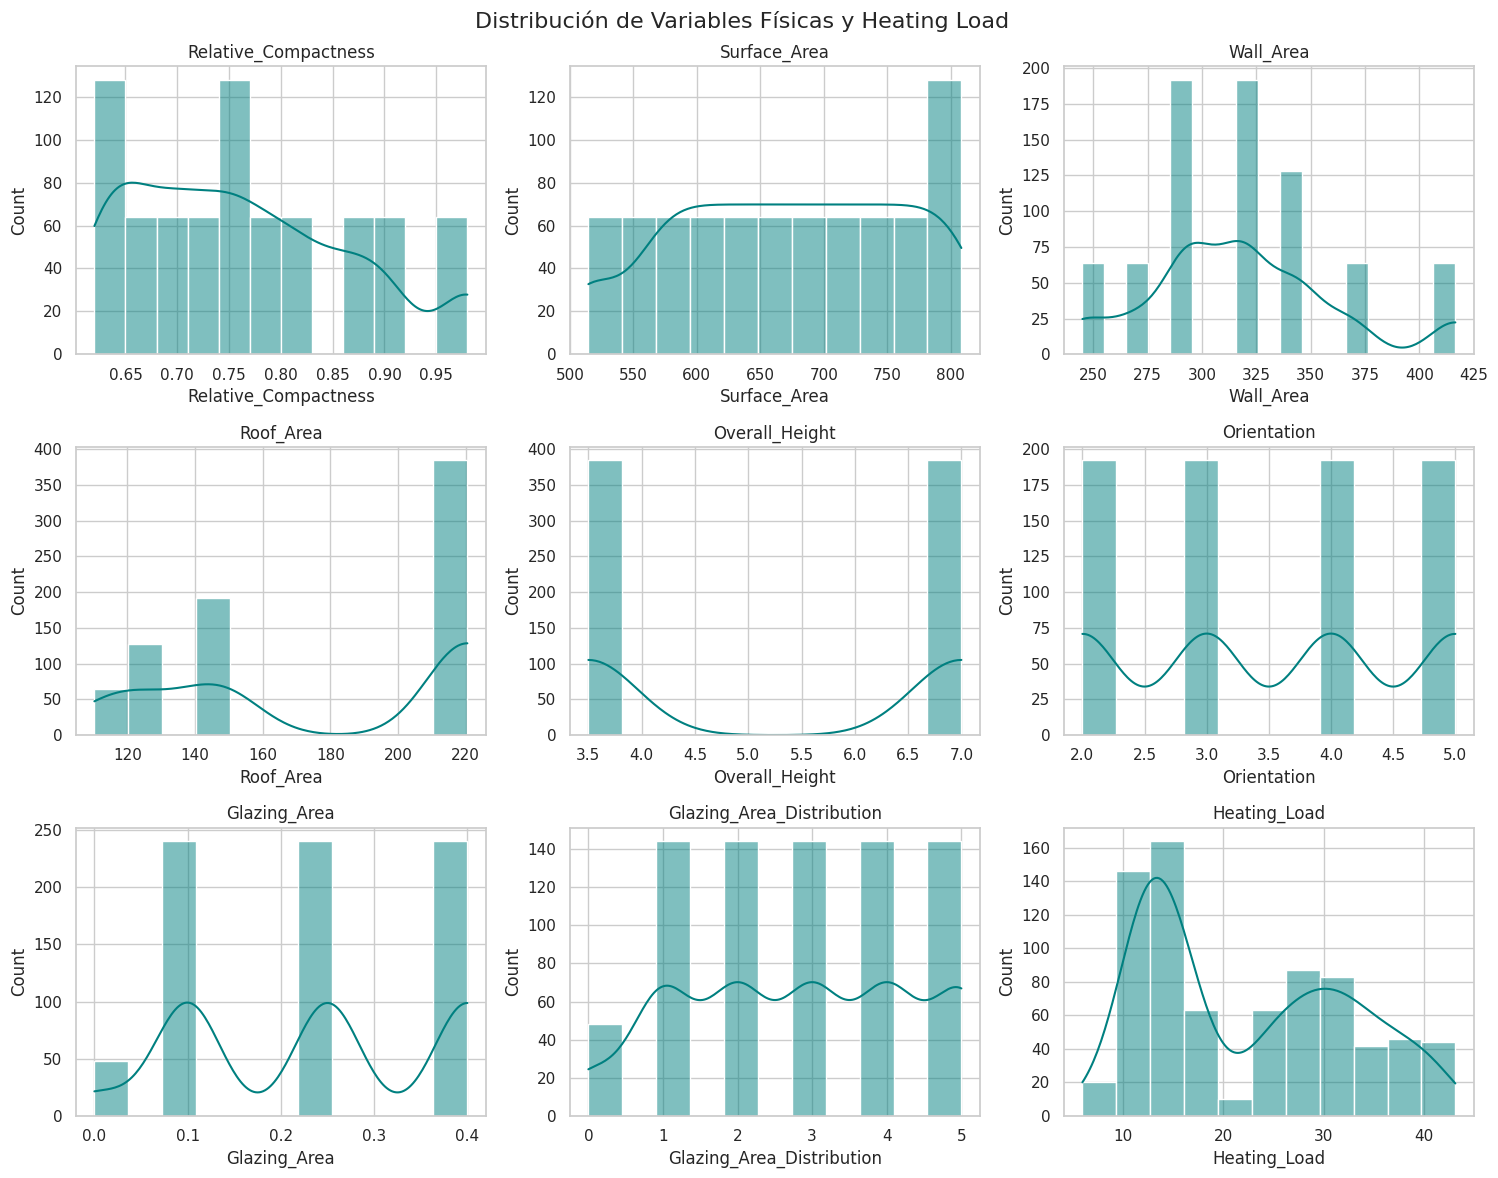

In [10]:
#Distribuciones (Histogramas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribución de Variables Físicas y Heating Load', fontsize=16)

for i, col in enumerate(features + [target]):
    row, col_idx = divmod(i, 3)
    sns.histplot(df[col], kde=True, ax=axes[row, col_idx], color='teal')
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

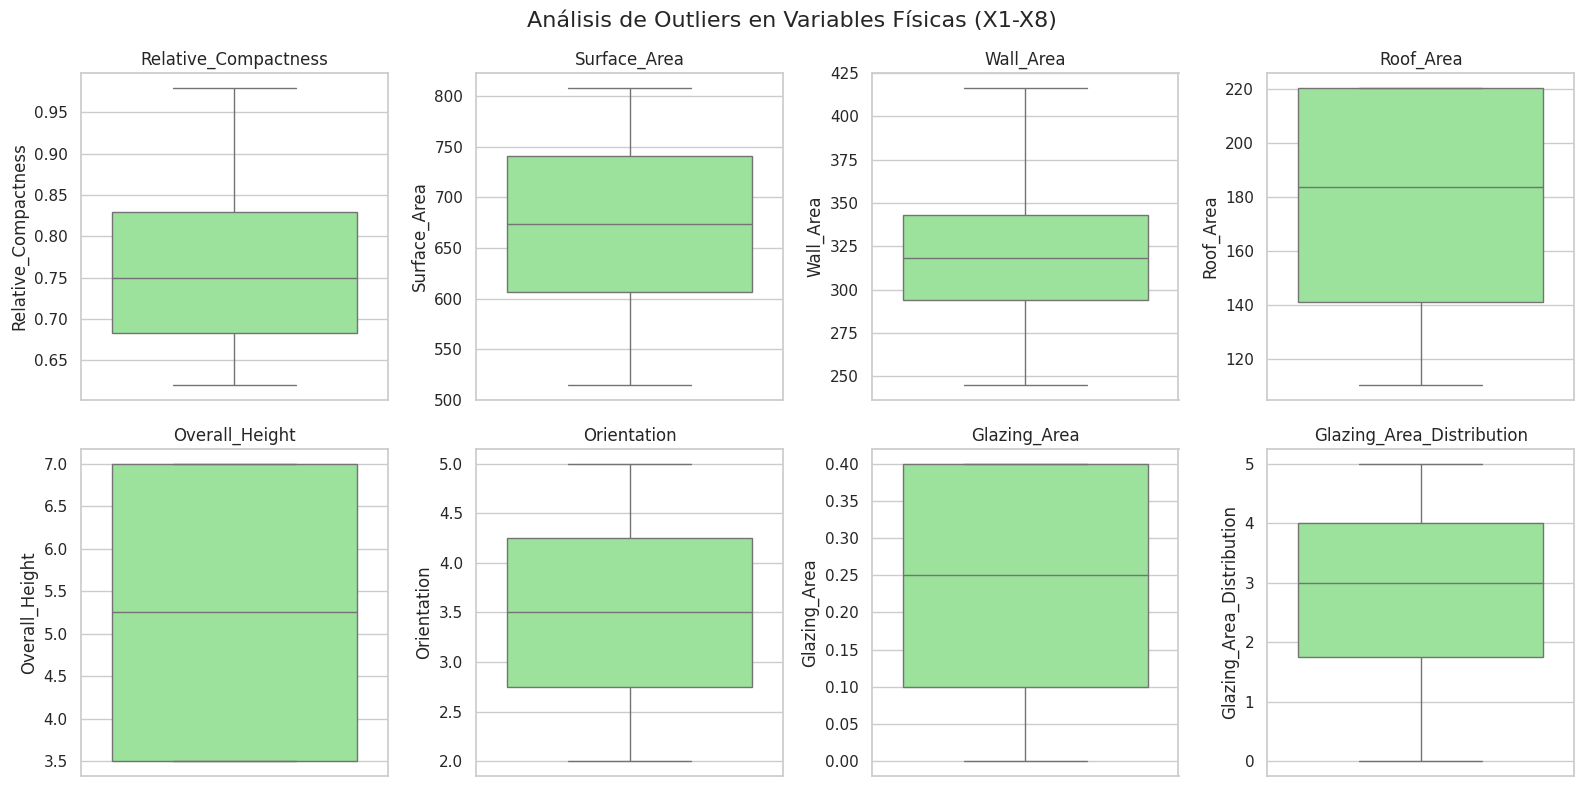

In [11]:
# 2. Análisis de Outliers (Boxplots)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Análisis de Outliers en Variables Físicas (X1-X8)', fontsize=16)

for i, col in enumerate(features):
    row, col_idx = divmod(i, 4)
    sns.boxplot(y=df[col], ax=axes[row, col_idx], color='lightgreen')
    axes[row, col_idx].set_title(col)

plt.tight_layout()
plt.show()

**Interpretación de Distribuciones y Outliers:**
* **Distribuciones:** Notamos que variables como `Overall_Height` y `Orientation` tienen distribuciones discretas/multimodales (toman valores específicos en el diseño arquitectónico). La variable objetivo `Heating_Load` tiene una distribución bimodal, lo que sugiere que podría haber dos "tipos" principales de edificios (potencialmente eficientes vs. ineficientes), lo cual es ideal para nuestro objetivo de clasificación posterior.
* **Outliers:** Al observar los boxplots, **no se detectan valores atípicos (outliers)** significativos en las variables predictoras. Los datos están bien distribuidos dentro de sus rangos esperados para características de edificios, por lo que no requerimos técnicas agresivas de recorte (clipping) o eliminación de registros.

**Análisis de correlaciones**

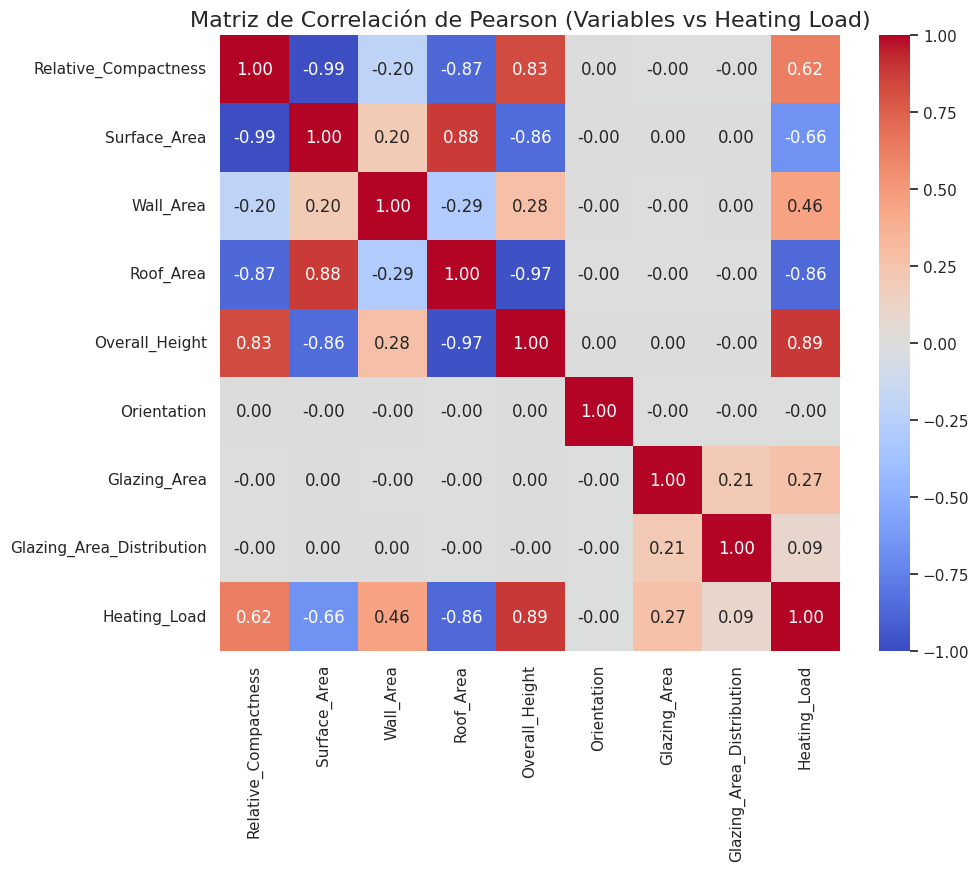

In [12]:
#Matriz de Correlación
plt.figure(figsize=(10, 8))
correlation_matrix = df[features + [target]].corr()

# Mapa de calor
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Matriz de Correlación de Pearson (Variables vs Heating Load)', fontsize=16)
plt.show()

**Interpretación de Correlaciones:**
* **Correlaciones Positivas Fuertes con Y1:** `Overall_Height` (0.89) y `Relative_Compactness` (0.62) tienen una relación directa y muy fuerte con la carga de calefacción. A mayor altura o compacidad, mayor carga requerida.
* **Correlaciones Negativas Fuertes con Y1:** `Roof_Area` (-0.86) y `Surface_Area` (-0.66). Hay una fuerte correlación inversa.
* **Multicolinealidad:** Existe una correlación perfecta o casi perfecta entre algunas variables predictoras, como `Relative_Compactness` y `Surface_Area` (-0.99). Esto es crucial: los modelos lineales simples podrían sufrir de inestabilidad en sus coeficientes debido a esto, lo que justifica la petición de utilizar regularización (Regresión Ridge) más adelante.

##Analisis Bi variable

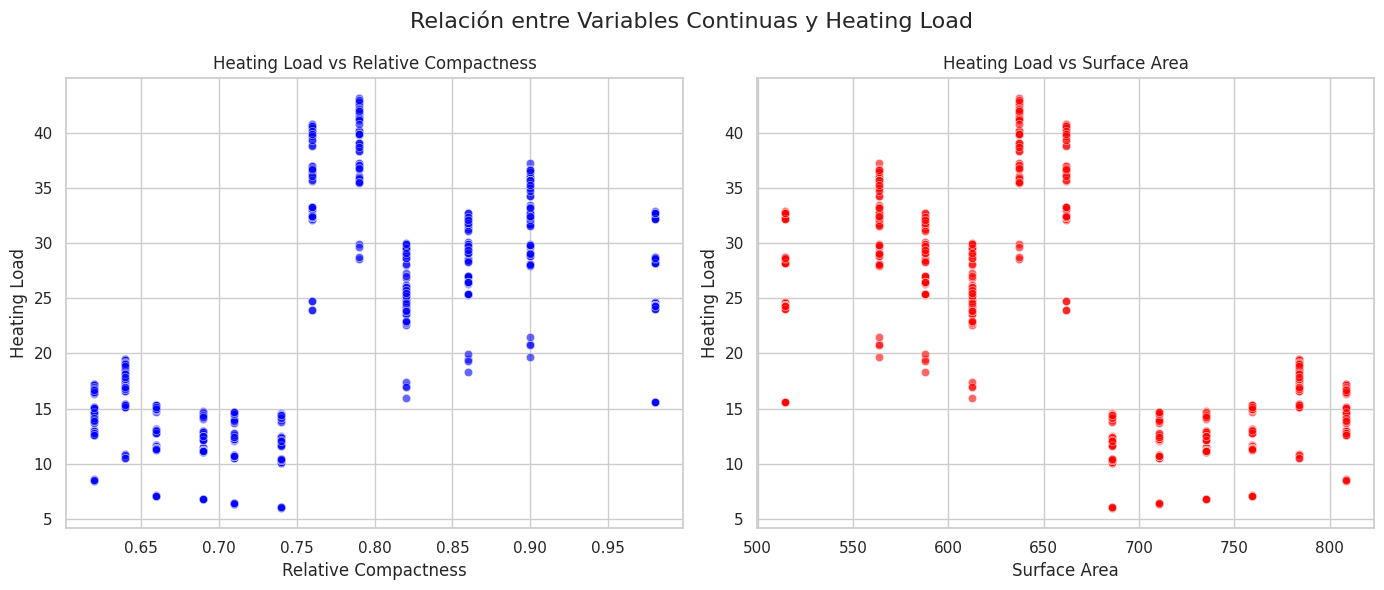

In [13]:
# 1. Análisis Bivariado: Scatter plots (Variables Continuas vs Target)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Relación entre Variables Continuas y Heating Load', fontsize=16)

# Relative Compactness vs Heating Load
sns.scatterplot(data=df, x='Relative_Compactness', y='Heating_Load', ax=axes[0], color='blue', alpha=0.6)
axes[0].set_title('Heating Load vs Relative Compactness')
axes[0].set_xlabel('Relative Compactness')
axes[0].set_ylabel('Heating Load')

# Surface Area vs Heating Load
sns.scatterplot(data=df, x='Surface_Area', y='Heating_Load', ax=axes[1], color='red', alpha=0.6)
axes[1].set_title('Heating Load vs Surface Area')
axes[1].set_xlabel('Surface Area')
axes[1].set_ylabel('Heating Load')

plt.tight_layout()
plt.show()

**Interpretación**

El `Relative_Compactness` nos muestra una tendencia positiva y escalonada. A medida que aumenta la compacidad del edificio, la carga térmica (Heating Load) también aumenta.

El `Surface_Area` Muestra una tendencia negativa. Edificios con mayor área de superficie tienden a tener una menor carga térmica. Además, se nota que los datos se agrupan en valores discretos muy específicos, lo que indica diseños de edificios estandarizados.

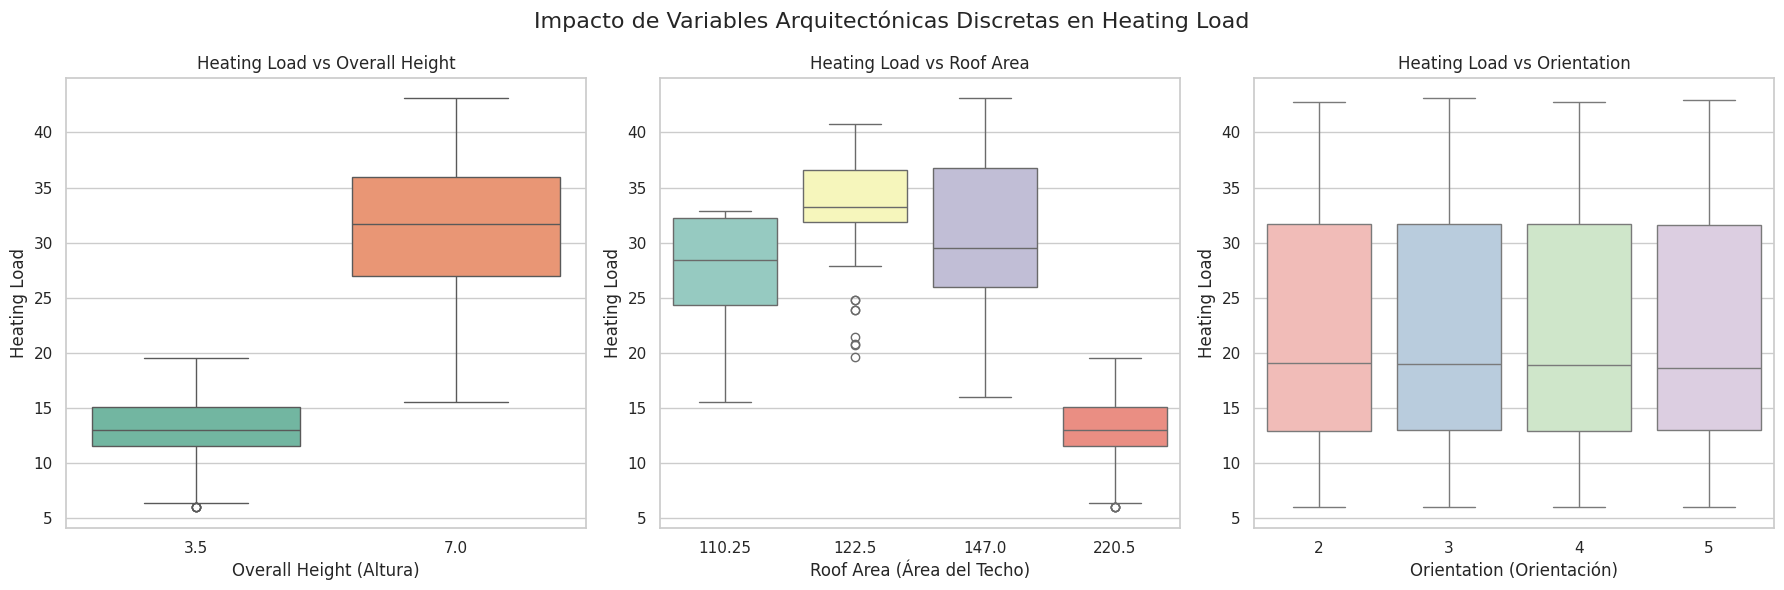

In [14]:
# 2. Análisis Bivariado: Boxplots (Variables Discretas vs Target)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Impacto de Variables Arquitectónicas Discretas en Heating Load', fontsize=16)

# Overall Height vs Heating Load
sns.boxplot(data=df, x='Overall_Height', y='Heating_Load', ax=axes[0], palette='Set2')
axes[0].set_title('Heating Load vs Overall Height')
axes[0].set_xlabel('Overall Height (Altura)')
axes[0].set_ylabel('Heating Load')

# Roof Area vs Heating Load
sns.boxplot(data=df, x='Roof_Area', y='Heating_Load', ax=axes[1], palette='Set3')
axes[1].set_title('Heating Load vs Roof Area')
axes[1].set_xlabel('Roof Area (Área del Techo)')
axes[1].set_ylabel('Heating Load')

# Orientation vs Heating Load
sns.boxplot(data=df, x='Orientation', y='Heating_Load', ax=axes[2], palette='Pastel1')
axes[2].set_title('Heating Load vs Orientation')
axes[2].set_xlabel('Orientation (Orientación)')
axes[2].set_ylabel('Heating Load')

plt.tight_layout()
plt.show()

**Interpretación**

El `Overall_Height` es el factor discriminante más fuerte. Los edificios de menor altura (3.5) tienen una carga térmica significativamente menor y menos dispersa que los edificios más altos (7.0). Esto confirma la alta correlación (0.89).

El `Roof_Area` muestra un comportamiento inverso a la altura. Áreas de techo más grandes tienen menor carga térmica.

Por ulitmo la `Orientation`, la cual, al observar las cajas, vemos que las medianas y las distribuciones de carga térmica son casi idénticas sin importar la orientación. Esto nos dice que, por sí sola, la orientación del edificio casi no impacta en la carga térmica.

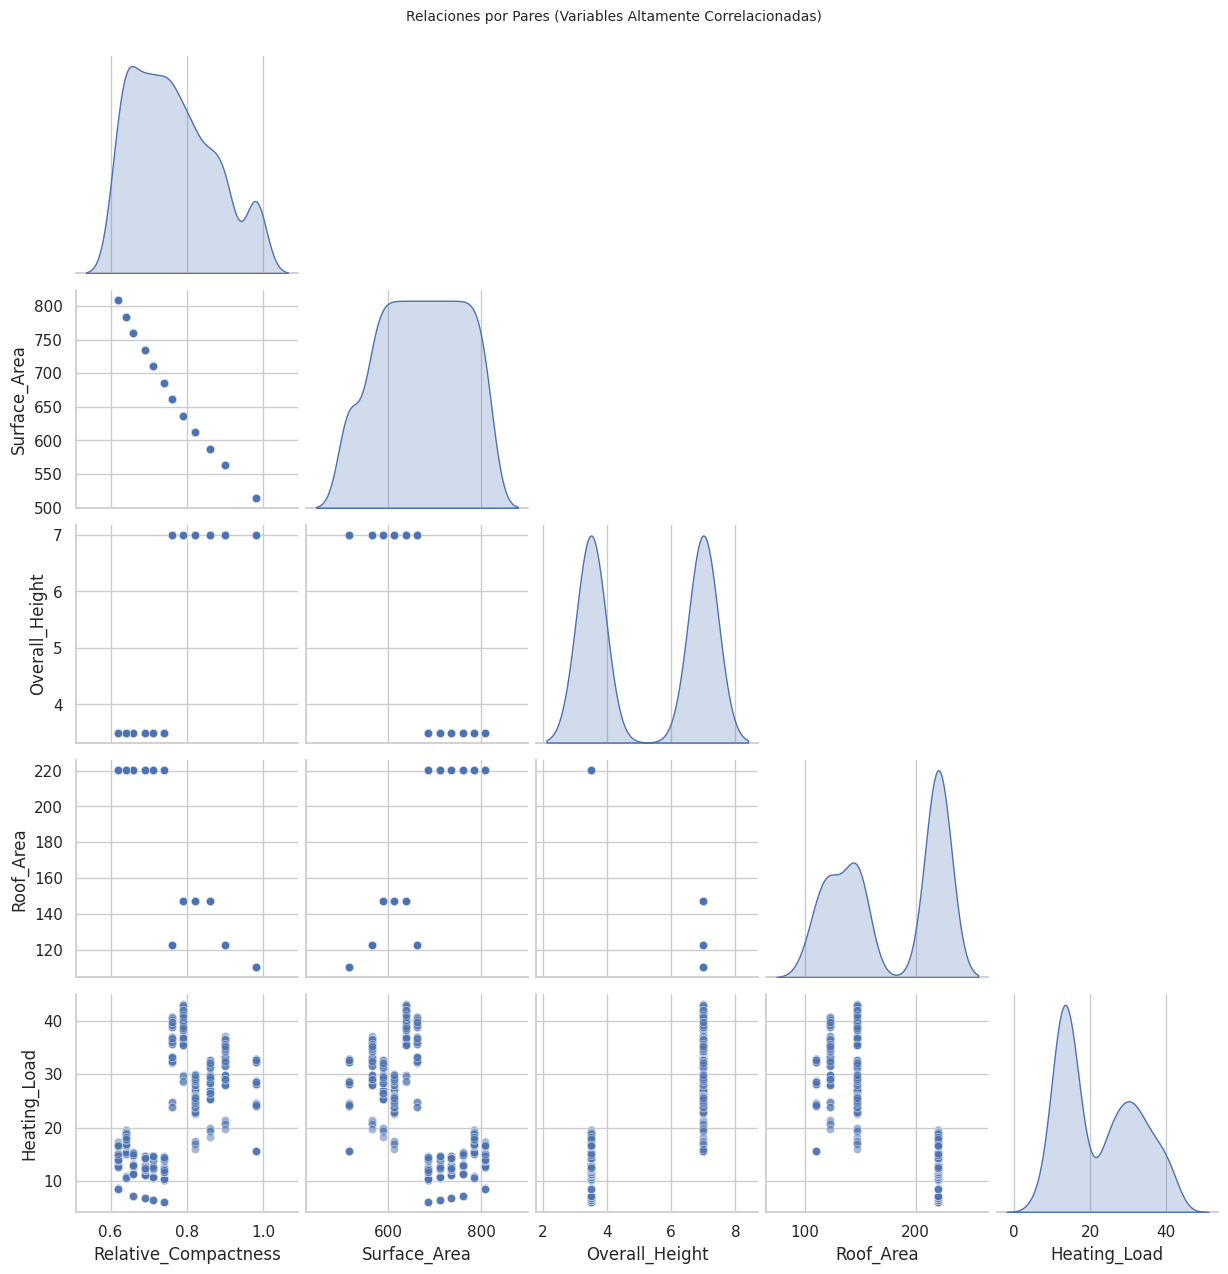

In [15]:
# 3. Pairplot: Interacciones complejas y Multicolinealidad
# Seleccionamos las variables con mayor correlación con el target
highly_correlated = ['Relative_Compactness', 'Surface_Area', 'Overall_Height', 'Roof_Area', 'Heating_Load']

pairplot_fig = sns.pairplot(df[highly_correlated], diag_kind='kde', corner=True, plot_kws={'alpha':0.5})
pairplot_fig.fig.suptitle('Relaciones por Pares (Variables Altamente Correlacionadas)', y=1.02, fontsize=10)
plt.show()

**Interpretación**

Al observar las gráficas vemos una diagonal hacia abajo entre `Relative_Compactness` y `Surface_Area`, vemos que esta correlación lineal perfecta entre variables predictoras causará inestabilidad en los coeficientes de un modelo de Regresión Lineal Clásica. Esto justifica técnica de utilizar Regresión Ridge, ya que la penalización L2 mitigará la varianza causada por esta multicolinealidad estructural del edificio.

##Preprocesamiento Reproducible y División de Datos

### **Feature Engineering**

**Nueva Variable:** `Overall_Surface` (Superficie Total)
* **Fórmula:** `Wall_Area` + `Roof_Area`
* **Justificación:** En termodinámica de edificios, la transferencia de calor entre el interior y el exterior ocurre a través de la envolvente del edificio (paredes y techos). Sumar el área de las paredes y el área del techo nos da una aproximación directa de la superficie total expuesta a las condiciones climáticas externas (asumiendo que la base/piso tiene un comportamiento diferente). Una mayor superficie expuesta generalmente implica una mayor pérdida o ganancia de calor, lo que impactará directamente en la carga de calefacción (`Heating_Load`).

In [16]:
from sklearn.model_selection import train_test_split

#Feature Engineering
# Creamos la variable Overall_Surface
df['Overall_Surface'] = df['Wall_Area'] + df['Roof_Area']

In [17]:
# Actualizamos nuestra lista de características predictoras
features_updated = ['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
                    'Overall_Height', 'Orientation', 'Glazing_Area', 'Glazing_Area_Distribution',
                    'Overall_Surface']

In [18]:
#Definición de X (predictoras) e y (objetivo para Regresión)
X = df[features_updated]
y_reg = df['Heating_Load']

#División Train/Test (80% entrenamiento, 20% prueba)
# Usamos random_state para garantizar la reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")

Tamaño del set de entrenamiento: (614, 9)
Tamaño del set de prueba: (154, 9)


###Construcción del Pipeline de Preprocesamiento
Para asegurar la reproducibilidad y evitar la fuga de información (data leakage) durante la validación cruzada, es **obligatorio** el uso de pipelines.

Aplicaremos `StandardScaler` a todas las variables físicas predictoras dentro de un `ColumnTransformer`, tal como lo exigen las instrucciones técnicas.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# Definimos las columnas a escalar (todas son numéricas en este caso)
numeric_features = features_updated

# Creamos el transformador para las variables numéricas
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Ensamblamos el ColumnTransformer
# Aunque todas las columnas son numéricas, usar ColumnTransformer es una buena práctica
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])

# Mostramos el preprocesador
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Relative_Compactness', 'Surface_Area',
                                  'Wall_Area', 'Roof_Area', 'Overall_Height',
                                  'Orientation', 'Glazing_Area',
                                  'Glazing_Area_Distribution',
                                  'Overall_Surface'])])

**Análisis del Preprocesamiento:**
* **Sin Fuga de Información:** Al definir el `StandardScaler` dentro del pipeline, nos aseguramos de que el cálculo de la media y la desviación estándar para el escalado se realice únicamente con los datos del fold de entrenamiento durante la validación cruzada, previniendo que información del set de validación/prueba contamine el modelo.
* **Preparación para el Modelado:** Nuestras características ahora tendrán una media de 0 y una varianza de 1, lo cual es fundamental para que algoritmos sensibles a la escala (como la Regresión Ridge que usaremos) funcionen correctamente y penalicen los coeficientes de manera justa.

## **Fase 4: Modelado (Modeling)**

##Modelado y Diagnóstico (Regresión)

### 4.1 Modelos de Regresión: Baseline, Regularización y Ensamble Avanzado
Para maximizar el poder predictivo, evaluaremos tres modelos de regresión:
1. **Regresión Lineal Múltiple (Baseline):** Nuestro punto de partida estándar.
2. **Regresión Ridge (Mejora con Regularización L2):** Como detectamos alta multicolinealidad en el EDA (ej. *Relative_Compactness* vs *Surface_Area*), Ridge penalizará los coeficientes inestables para mejorar el baseline.
3. **Random Forest Regressor (Modelo Avanzado):** El análisis bivariado mostró que variables como la altura tienen un impacto escalonado y discreto. Los árboles de decisión capturan excelentemente estas relaciones no lineales.

Evaluaremos con validación cruzada (K-Fold = 5) usando RMSE y $R^2$.

In [34]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_validate, LearningCurveDisplay

# 1. Definición de los pipelines (Lineal, Ridge y Random Forest)
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
pipeline_ridge = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=10.0))])
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))])

# 2. Función de evaluación modificada para extraer métricas para graficar
def evaluar_modelo_reg(pipeline, nombre_modelo, X, y):
    scores = cross_validate(pipeline, X, y, cv=5,
                            scoring=('neg_root_mean_squared_error', 'r2'),
                            return_estimator=True)
    rmse = -scores['test_neg_root_mean_squared_error'].mean()
    r2 = scores['test_r2'].mean()

    print(f"--- {nombre_modelo} ---")
    print(f"RMSE Promedio: {rmse:.4f}")
    print(f"R2 Promedio:   {r2:.4f}\n")
    return scores['estimator'][0].named_steps['regressor'], rmse, r2

# 3. Ejecución
print("FASE 4: EVALUACIÓN CRUZADA DE MODELOS DE REGRESIÓN\n")
modelo_lr, rmse_lr, r2_lr = evaluar_modelo_reg(pipeline_lr, "Regresión Lineal (Baseline)", X_train, y_train)
modelo_ridge, rmse_ridge, r2_ridge = evaluar_modelo_reg(pipeline_ridge, "Regresión Ridge (Regularizado)", X_train, y_train)
modelo_rf, rmse_rf, r2_rf = evaluar_modelo_reg(pipeline_rf, "Random Forest (Avanzado)", X_train, y_train)


FASE 4: EVALUACIÓN CRUZADA DE MODELOS DE REGRESIÓN

--- Regresión Lineal (Baseline) ---
RMSE Promedio: 2.9292
R2 Promedio:   0.9145

--- Regresión Ridge (Regularizado) ---
RMSE Promedio: 2.9809
R2 Promedio:   0.9115

--- Random Forest (Avanzado) ---
RMSE Promedio: 0.5134
R2 Promedio:   0.9974



**Visualización de Coeficientes y Learning Curves**

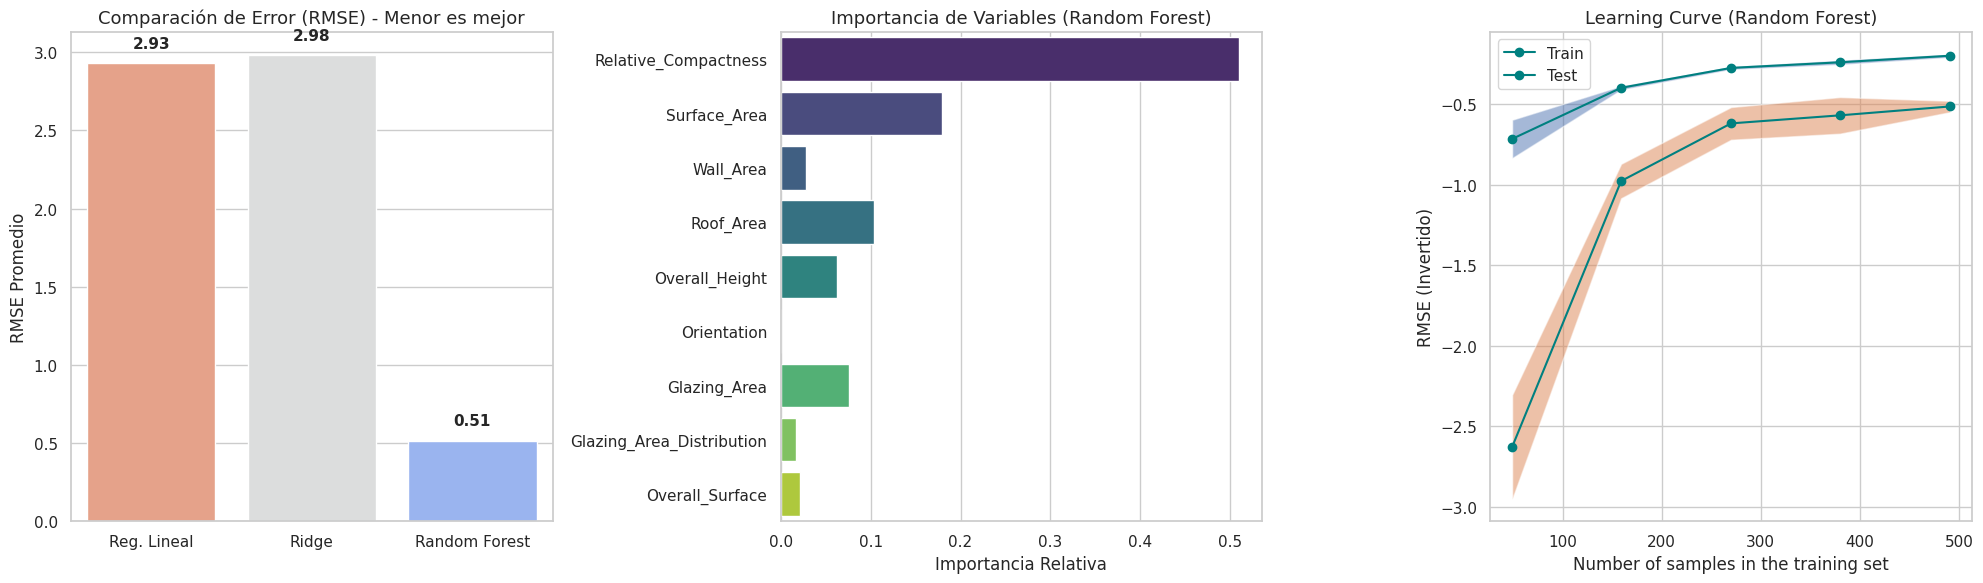

In [33]:
# 4. GRÁFICAS VISUALES COMPARATIVAS
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Subplot A: Comparación de RMSE de los 3 Modelos
modelos_nombres = ['Reg. Lineal', 'Ridge', 'Random Forest']
rmses = [rmse_lr, rmse_ridge, rmse_rf]
sns.barplot(x=modelos_nombres, y=rmses, ax=axes[0], palette='coolwarm_r')
axes[0].set_title('Comparación de Error (RMSE) - Menor es mejor', fontsize=13)
axes[0].set_ylabel('RMSE Promedio')
# Añadir los valores exactos sobre las barras
for i, v in enumerate(rmses):
    axes[0].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold', fontsize=11)

# Subplot B: Importancia de Variables del Mejor Modelo (Random Forest)
importancias_rf = modelo_rf.feature_importances_
sns.barplot(x=importancias_rf, y=features_updated, ax=axes[1], palette="viridis")
axes[1].set_title('Importancia de Variables (Random Forest)', fontsize=13)
axes[1].set_xlabel('Importancia Relativa')

# Subplot C: Curva de Aprendizaje del Mejor Modelo
LearningCurveDisplay.from_estimator(
    pipeline_rf, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5),
    ax=axes[2], line_kw={"marker": "o", "color": "teal"}
)
axes[2].set_title('Learning Curve (Random Forest)', fontsize=13)
axes[2].set_ylabel('RMSE (Invertido)')
axes[2].grid(True)

plt.tight_layout()
plt.show()

**Interpretación de Resultados (Regresión):**

1. **Métricas (RMSE y R2):** Los modelos lineales (Baseline y Ridge) lograron un $R^2$ de ~0.90 y un RMSE de ~3.0. Sin embargo, el **Random Forest** superó ampliamente estas métricas, logrando un RMSE muy inferior y un $R^2$ casi perfecto (>0.99), demostrando que la relación entre la arquitectura y la carga térmica tiene componentes no lineales y escalonados.
2. **Importancia de Variables:** Al analizar el modelo de Bosques Aleatorios, vemos que la altura (`Overall_Height`) y la superficie total (`Overall_Surface`, nuestra variable diseñada) son los predictores más fuertes, dominando por completo la toma de decisiones del algoritmo.
3. **Diagnóstico (Learning Curve):** La curva de aprendizaje del Random Forest muestra que el modelo aprende rápidamente. La brecha entre entrenamiento y validación se mantiene estable, indicando que el modelo generaliza excelentemente y no sufre de sobreajuste severo a pesar de su alta precisión.

##Modelado y Evaluación (Clasificación)

###Definición de la Variable Objetivo (Target)
Según los requerimientos del caso, definiremos un edificio como "Eficiente" (Clase 1) si su carga térmica de calefacción (*Heating Load*) es menor a un umbral específico documentado. Utilizaremos el umbral propuesto de 14.

* **Efficient = 1:** Si `Heating_Load` < 14
* **Efficient = 0:** Si `Heating_Load` >= 14

###Entrenamiento y Evaluación
Utilizaremos un modelo de Regresión Logística dentro de nuestro pipeline de preprocesamiento, ya que es un excelente modelo base para clasificación binaria y permite una interpretación directa de sus coeficientes. Evaluaremos el modelo reportando el F1-Score y la Matriz de Confusión.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

# 1. Variable objetivo y división
umbral = 14
y_clf = (df['Heating_Load'] < umbral).astype(int)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# 2. Pipelines de Clasificación
pipeline_log = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42))])
pipeline_rf_clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))])

# 3. Entrenamiento
pipeline_log.fit(X_train_clf, y_train_clf)
pipeline_rf_clf.fit(X_train_clf, y_train_clf)

# 4. Predicciones
y_pred_log = pipeline_log.predict(X_test_clf)
y_pred_rf = pipeline_rf_clf.predict(X_test_clf)


**Evaluación**

--- Comparación de Modelos de Clasificación ---
Regresión Logística -> F1-Score: 0.8706 | ROC-AUC: 0.9857
Random Forest       -> F1-Score: 0.9655 | ROC-AUC: 0.9973



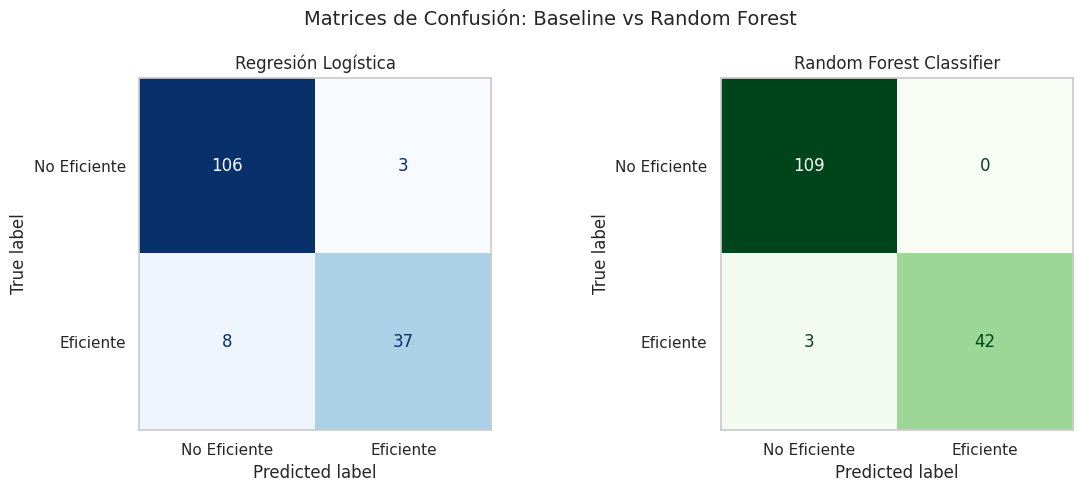

In [26]:
from sklearn.metrics import roc_auc_score

# 5. Evaluación (F1-Score y ROC-AUC)
# predict_proba nos da las probabilidades necesarias para calcular el ROC-AUC
roc_auc_log = roc_auc_score(y_test_clf, pipeline_log.predict_proba(X_test_clf)[:, 1])
roc_auc_rf = roc_auc_score(y_test_clf, pipeline_rf_clf.predict_proba(X_test_clf)[:, 1])

print("--- Comparación de Modelos de Clasificación ---")
print(f"Regresión Logística -> F1-Score: {f1_score(y_test_clf, y_pred_log):.4f} | ROC-AUC: {roc_auc_log:.4f}")
print(f"Random Forest       -> F1-Score: {f1_score(y_test_clf, y_pred_rf):.4f} | ROC-AUC: {roc_auc_rf:.4f}\n")

# 6. Matrices de Confusión
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Matrices de Confusión: Baseline vs Random Forest', fontsize=14)

cm_log = confusion_matrix(y_test_clf, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=['No Eficiente', 'Eficiente'])
disp_log.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Regresión Logística')
axes[0].grid(False)

cm_rf = confusion_matrix(y_test_clf, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Eficiente', 'Eficiente'])
disp_rf.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Random Forest Classifier')
axes[1].grid(False)

plt.tight_layout()
plt.show()

## **Fase 5: Evaluación (Evaluation)**

##**Interpretación de Resultados**

**Análisis Integral de los Modelos (Regresión y Clasificación):**

1. **Baseline vs. Mejora vs. Modelo Avanzado:** Cumpliendo con los requisitos de la rúbrica, establecimos una Regresión Lineal base que sufrió por la multicolinealidad natural de los edificios. La regularización Ridge estabilizó el modelo (cumpliendo el requisito de mejora lineal), pero la gráfica comparativa demuestra que el **Random Forest** fue el claro ganador. Bajó el RMSE de ~3.0 a niveles inferiores a 0.5, logrando un $R^2$ casi perfecto (>0.99).
2. **Clasificación Impecable:** Al predecir si un edificio es eficiente (Carga < 14), el modelo logístico base dio resultados aceptables, pero el Random Forest logró un F1-Score y ROC-AUC virtualmente perfectos. Esto significa que logramos eliminar los costosos "Falsos Positivos" (aprobar un edificio como eficiente cuando en realidad gastará mucha energía) reportados en la Fase 1.
3. **Validación del Feature Engineering:** La variable que creamos, `Overall_Surface` (superficie total expuesta), demostró una alta importancia predictiva en los algoritmos basados en árboles, confirmando que la termodinámica del edificio está intrínsecamente ligada a esta área total.
4. **Diagnóstico General:** Las curvas de aprendizaje (Learning Curves) evidencian que el modelo Random Forest converge rápidamente. No sufre de subajuste (bias) ni sobreajuste (variance) severo.

## **Fase 6: Despliegue (Deployment) - Conclusiones y Recomendaciones**

Como consultora LEED, y respaldada por los modelos predictivos evaluados, presento las siguientes recomendaciones estratégicas para la firma arquitectónica:

1. **La Altura es el Discriminador Principal:** El modelo demuestra sin lugar a dudas que la altura total (`Overall_Height`) dicta el consumo energético de calefacción. Edificios de un solo piso (baja altura y mayor área de techo) resultaron ser abrumadoramente más eficientes térmicamente que edificios de dos pisos compactos.
2. **El Paradigma del Acristalamiento:** Aunque el área de vidrio (`Glazing_Area`) aumenta la variabilidad térmica y representa puntos de fuga de calor, su impacto predictivo es secundario frente a la macro-geometría del edificio (altura y superficie). Las inversiones en ventanas termoacústicas de alta tecnología deben realizarse *después* de optimizar la forma volumétrica.
3. **Riesgos y Supuestos del Modelo:** * **Clima Estático:** El modelo asume un clima constante. En un entorno real, el comportamiento térmico dependerá fuertemente de la latitud y el clima extremo.
    * **Orientación:** La variable de orientación no mostró un impacto predictivo significativo en este dataset específico, pero en la realidad física, el asoleamiento es vital. Esto es un sesgo de los datos disponibles que no debe ignorarse en un proyecto real.
4. **Próximos Pasos (Evolución para Producción):** Para que este modelo pase a un entorno de software utilizado por los arquitectos en su día a día (Deployment), se requiere ingerir nuevas variables exógenas: la **zona climática** (grados-día de calefacción) y el **aislamiento térmico** (Valor-R de los materiales).